In [ ]:
# Projecto Itaca

In [1]:
import json
import os
import platform
import time
from datetime import datetime


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

## Montar Drive en Colab Content

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Rutas Relativas a Directoriso de Trabajo

In [5]:
PROJECT_ROOT = "/content/drive/MyDrive/Itaca"

In [6]:
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "preprocessing", "output")
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "preprocessing", "artifacts")
SPLITS_DIR = os.path.join(PROJECT_ROOT, "preprocessing", "splits")
MODEL_DIR = os.path.join(PROJECT_ROOT, "model")


In [7]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [8]:
SEED = 42

In [9]:
MAX_TOKENS = 150
SEQUENCE_LENGTH = 16
EMBEDDING_DIM = 32

##  Hyperparametros del Modelo a Construir

In [10]:
TAB_DENSE_1 = 64  # Capa Tabular 1
TAB_DENSE_2 = 32   # Primera Capa Densa
TEXT_DENSE = 32    # Segunda Capa Texto
HEAD_DENSE_1 = 64  # Cabezal Denso I
HEAD_DENSE_2 = 32  # Cabezal Denso II

In [11]:
DROPOUT_BRANCH = 0.3  # PDropOut 0.3 -> Evitar Overfitting
DROPOUT_HEAD_1 = 0.3  # DropOut 0.3 en cabezal I
DROPOUT_HEAD_2 = 0.2  # DropOut 0.2 en Cabezal II

In [12]:
LEARNING_RATE = 1e-3  # LR
BATCH_SIZE = 32  # Tamaño del Batch Size
MAX_EPOCHS = 100  # Numero de Epocas
EARLY_STOP_PATIENCE = 10  #  Parada Rapida antes de Sobre Ajuste cuando el modelo No mejore mas
LR_PLATEAU_PATIENCE = 5  #  LR descenso en Entrenamiento plan osi nmejoras
LR_PLATEAU_FACTOR = 0.5   # Fraccion de Aplanamiento para LR

In [13]:
N_CLASSES = 4   #  Numero de Clases , Input Vars del Modelo

In [14]:
keras.utils.set_random_seed(SEED)  # Deninir Semilla 42
np.random.seed(SEED)

##  Verificar Version de TensorFlow &  Keras

In [ ]:
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")


TensorFlow: 2.20.0
Keras: 3.13.2
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Confirmar version de Sklearn en Colab
Importante para la construccion Backend

In [ ]:
import sklearn, numpy
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
numpy: 2.0.2


## Cargar Artefactos desde Drive en Directorios pre definidos y montados.

In [17]:
# Load Artifacts
def load_split(name):

    X_tab = np.load(os.path.join(OUTPUT_DIR, f"X_tab_{name}.npy")).astype("float32")  # Fload 32 para mejor precisison .
    X_text = np.load(os.path.join(OUTPUT_DIR, f"X_text_{name}.npy")).astype("int32")
    y = np.load(os.path.join(OUTPUT_DIR, f"y_{name}.npy")).astype("int64")

    return X_tab, X_text, y

## Declaracion de Variables de Entrada al Modelo

In [16]:
X_tab_train, X_text_train, y_train = load_split("train")
X_tab_val, X_text_val, y_val = load_split("val")
X_tab_test, X_text_test, y_test = load_split("test")

## Artefactos Generados Durante el ETl Semana I

In [18]:
with open(os.path.join(ARTIFACTS_DIR, "class_map.json"), encoding="utf-8") as f:

    class_map = json.load(f)
    print(class_map)


{'Inicial': 0, 'En Desarrollo': 1, 'Definido': 2, 'Optimizado': 3}


In [19]:
inv_class_map = {v: k for k, v in class_map.items()}
CLASS_NAMES = [inv_class_map[i] for i in range(N_CLASSES)]

In [20]:
with open(os.path.join(ARTIFACTS_DIR, "class_weights.json"), encoding="utf-8") as f:
    class_weights = {int(k): float(v) for k, v in json.load(f).items()}


In [21]:
with open(os.path.join(ARTIFACTS_DIR, "vocab.txt"), encoding="utf-8") as f:
    vocabulary = [line.rstrip("\n") for line in f]

In [22]:
N_TAB_FEATURES = X_tab_train.shape[1]

In [23]:
print("Shapes cargadas")
print(f"  train: tab={X_tab_train.shape}  text={X_text_train.shape}  y={y_train.shape}")
print(f"  val:   tab={X_tab_val.shape}  text={X_text_val.shape}  y={y_val.shape}")
print(f"  test:  tab={X_tab_test.shape}  text={X_text_test.shape}  y={y_test.shape}")
print(f"\nClases: {CLASS_NAMES}")
print(f"Class Weights: {class_weights}")
print(f"Vocab : {len(vocabulary)} tokens")

Shapes cargadas
  train: tab=(2250, 10)  text=(2250, 16)  y=(2250,)
  val:   tab=(450, 10)  text=(450, 16)  y=(450,)
  test:  tab=(300, 10)  text=(300, 16)  y=(300,)

Clases: ['Inicial', 'En Desarrollo', 'Definido', 'Optimizado']
Class Weights: {0: 0.9583, 1: 0.8117, 2: 0.8236, 3: 1.9599}
Vocab : 108 tokens


##  VALIDACIONES PREVIAS AL ENTRENAMIENTO

In [ ]:
assert X_tab_train.shape[0] == X_text_train.shape[0] == y_train.shape[0], \
    "Desalineacion de filas en train"
assert X_tab_val.shape[0] == X_text_val.shape[0] == y_val.shape[0], \
    "Desalineacion de filas en val"
assert X_tab_test.shape[0] == X_text_test.shape[0] == y_test.shape[0], \
    "Desalineacion de filas en test"

In [ ]:
assert X_text_train.shape[1] == SEQUENCE_LENGTH, \
    f"SEQUENCE_LENGTH ({SEQUENCE_LENGTH}) no coincide con los tensores de texto"
assert len(vocabulary) <= MAX_TOKENS, \
    f"El vocabulario ({len(vocabulary)}) excede MAX_TOKENS ({MAX_TOKENS})"

In [ ]:
max_token_idx = int(max(X_text_train.max(), X_text_val.max(), X_text_test.max()))
assert max_token_idx < MAX_TOKENS, \
    f"Indice de token {max_token_idx} fuera del rango del Embedding ({MAX_TOKENS})"

In [ ]:
assert set(np.unique(y_train)) <= set(range(N_CLASSES)), "Etiquetas fuera de rango"
assert sorted(class_weights.keys()) == list(range(N_CLASSES)), \
    "class_weights no cubre las 4 clases"

In [ ]:
print(f"  Indice maximo de token: {max_token_idx} (limite Embedding: {MAX_TOKENS})")

  Indice maximo de token: 107 (limite Embedding: 150)


## COUNSTRUCCION DEL MODELO

In [ ]:

def build_model(use_tabular=True, use_text=True, name="smartdiag"):
    """Construye la DNN multimodal.

    Los flags use_tabular/use_text permiten construir las variantes
    del estudio de ablacion sin duplicar codigo por esto centralizamos la arquitectura
    del Modelo en esta funcion general para Analisis Abalcion.
    """
    if not (use_tabular or use_text):
        raise ValueError("El modelo requiere al menos una rama activa.")
    # StartUp
    inputs = []
    branches = []

    # Rama tabular
    if use_tabular:
        tab_input = keras.Input(shape=(N_TAB_FEATURES,), dtype="float32",
                                name="tabular_input")
        inputs.append(tab_input)
        # Construccion de la Rama Tabular.
        t = layers.Dense(TAB_DENSE_1, activation="relu", name="tab_dense_1")(tab_input)
        t = layers.BatchNormalization(name="tab_bn")(t)
        t = layers.Dropout(DROPOUT_BRANCH, name="tab_dropout")(t)
        t = layers.Dense(TAB_DENSE_2, activation="relu", name="tab_dense_2")(t)
        branches.append(t)

    #  Rama NLP
    if use_text:
        text_input = keras.Input(shape=(SEQUENCE_LENGTH,), dtype="int32",
                                 name="text_input")
        inputs.append(text_input)

        # input_dim = MAX_TOKENS (no len(vocabulary)): la matriz debe cubrir
        # todo el espacio de indices que TextVectorization puede emitir.
        # mask_zero=True es critico: el 96% de las secuencias tienen padding y

        e = layers.Embedding(
            input_dim=MAX_TOKENS,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="text_embedding",
        )(text_input) # sin mascara el pooling promediaria los ceros junto con los tokens reales.

        e = layers.GlobalAveragePooling1D(name="text_pooling")(e)
        e = layers.Dense(TEXT_DENSE, activation="relu", name="text_dense")(e)

        branches.append(e)

    #  Fusion tardia de lasdos ramas densas
    if len(branches) > 1:
        x = layers.Concatenate(name="fusion")(branches)
    else:
        x = branches[0]

    #  Cabeza de clasificacion
    x = layers.Dense(HEAD_DENSE_1, activation="relu", name="head_dense_1")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(DROPOUT_HEAD_1, name="head_dropout_1")(x)
    x = layers.Dense(HEAD_DENSE_2, activation="relu", name="head_dense_2")(x)
    x = layers.Dropout(DROPOUT_HEAD_2, name="head_dropout_2")(x)

    outputs = layers.Dense(N_CLASSES, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

##  Construccion del Modelo Principal por Entrenar

In [ ]:
model = build_model(name="smartdiag_multimodal")

## Ver Hyperparametros

In [ ]:
model.summary()

Model: "smartdiag_multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_1 (Dense) │ (None, 64)        │        704 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_bn              │ (None, 64)        │        256 │ tab_dense_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 16, 32)    │      4,800 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 16)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dropout         │ (None, 64)        │          0 │ tab_bn[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_pooling        │ (None, 32)        │          0 │ text_embedding[0… │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_2 (Dense) │ (None, 32)        │      2,080 │ tab_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense (Dense)  │ (None, 32)        │      1,056 │ text_pooling[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 64)        │          0 │ tab_dense_2[0][0… │
│ (Concatenate)       │                   │            │ text_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 64)        │      4,160 │ fusion[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn             │ (None, 64)        │        256 │ head_dense_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_1      │ (None, 64)        │          0 │ head_bn[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_2        │ (None, 32)        │      2,080 │ head_dropout_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_2      │ (None, 32)        │          0 │ head_dense_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        132 │ head_dropout_2[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,524 (60.64 KB)

 Trainable params: 15,268 (59.64 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
##  Guardar Arquitecutra del Modelo para Informe Tecnico

In [ ]:
try:
    keras.utils.plot_model(
        model,
        to_file=os.path.join(MODEL_DIR, "architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        dpi=120,
    )
    print("Diagrama guardado: model/architecture.png")
except Exception as exc:
    print(f"No se pudo generar el diagrama (opcional): {exc}")


Diagrama guardado: model/architecture.png


In [ ]:
# TRAINING

In [ ]:
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "checkpoint_best.keras")

## Definir Callbacks del Modelo  
Importante para Optimizacion del training Loop

In [ ]:

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=LR_PLATEAU_FACTOR,
        patience=LR_PLATEAU_PATIENCE,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [ ]:
# Training

In [ ]:
start_time = time.time()

history = model.fit(
    x={"tabular_input": X_tab_train, "text_input": X_text_train},
    y=y_train,
    validation_data=(
        {"tabular_input": X_tab_val, "text_input": X_text_val},
        y_val,
    ),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.5613 - loss: 1.0312 - val_accuracy: 0.9156 - val_loss: 0.9877 - learning_rate: 0.0010
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8920 - loss: 0.3187 - val_accuracy: 0.9844 - val_loss: 0.2212 - learning_rate: 0.0010
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9871 - loss: 0.0843 - val_accuracy: 1.0000 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9947 - loss: 0.0408 - val_accuracy: 1.0000 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9982 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.0148 - val_accuracy: 1.0000 - val_loss: 3.8969e-04 - learning_rate: 0.0010
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9996 - loss: 0.0104 - 

In [ ]:
#  Logs de Entrenamientos Reporte

In [ ]:
training_time = time.time() - start_time
epochs_run = len(history.history["loss"])

In [ ]:
print(f"Training Completed {training_time:.1f} seg  -> ({epochs_run} epochs )")

Training Completed 51.6 seg  -> (67 epochs )


In [ ]:
#  Graficar Curvas de Entrenamiento para Reporte Final.

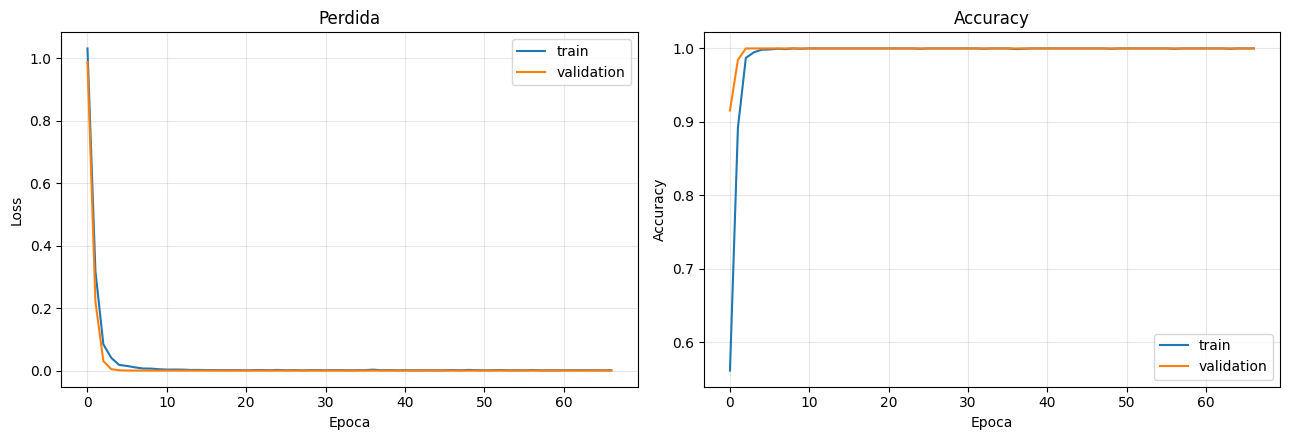

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Perdida")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "training_curves.png"), dpi=140,
            bbox_inches="tight")

plt.show()

In [ ]:
# EVALUACION SOBRE TEST Set

In [ ]:
test_inputs = {"tabular_input": X_tab_test, "text_input": X_text_test}

In [ ]:
y_proba = model.predict(test_inputs, verbose=0)
y_pred = y_proba.argmax(axis=1)

In [ ]:
test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
test_f1_weighted = f1_score(y_test, y_pred, average="weighted")

In [ ]:
print(f"Accuracy:     {test_accuracy:.4f}")
print(f"F1 macro:     {test_f1_macro:.4f}   ")
print(f"F1 ponderado: {test_f1_weighted:.4f}")

Accuracy:     1.0000
F1 macro:     1.0000   
F1 ponderado: 1.0000


In [ ]:
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))


Reporte por clase:
               precision    recall  f1-score   support

      Inicial     1.0000    1.0000    1.0000        79
En Desarrollo     1.0000    1.0000    1.0000        92
     Definido     1.0000    1.0000    1.0000        91
   Optimizado     1.0000    1.0000    1.0000        38

     accuracy                         1.0000       300
    macro avg     1.0000    1.0000    1.0000       300
 weighted avg     1.0000    1.0000    1.0000       300



In [ ]:
report_dict = classification_report(
    y_test, y_pred, target_names=CLASS_NAMES, output_dict=True, digits=4
)

In [ ]:
## Metricas de ML

In [ ]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)

In [ ]:
## Grafico de Matrix de Confusion

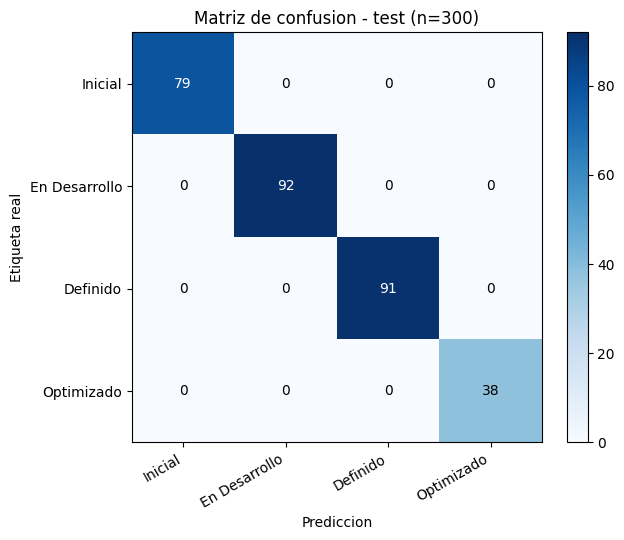

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=30, ha="right")
ax.set_yticks(range(N_CLASSES), CLASS_NAMES)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Etiqueta real")
ax.set_title(f"Matriz de confusion - test (n={len(y_test)})")

threshold = cm.max() / 2.0
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > threshold else "black")

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_matrix.png"), dpi=140,
            bbox_inches="tight")
plt.show()


## ANALISIS DE CASOS FRONTERA

In [ ]:
BOUNDARY_VALUES = [0.20, 0.50, 0.80]

## Patron de Bandas ya identificado en Dataset Sintentico desde Semanan I

In [ ]:
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))
boundary_mask = test_df["porcentaje_procesos_documentados"].isin(BOUNDARY_VALUES).values


In [ ]:
n_boundary = int(boundary_mask.sum())
print(f"Registros en valores frontera dentro de test: {n_boundary}")


Registros en valores frontera dentro de test: 8


In [ ]:
## Evaluacion de Casos Fronteras

In [ ]:
boundary_stats = {"n_boundary": n_boundary}

In [ ]:

if n_boundary > 0:
    acc_boundary = accuracy_score(y_test[boundary_mask], y_pred[boundary_mask])
    acc_regular = accuracy_score(y_test[~boundary_mask], y_pred[~boundary_mask])

    conf_boundary = float(y_proba[boundary_mask].max(axis=1).mean())
    conf_regular = float(y_proba[~boundary_mask].max(axis=1).mean())

    print(f"  Accuracy en frontera:    {acc_boundary:.4f}")
    print(f"  Accuracy en el resto:    {acc_regular:.4f}")
    print(f"  Confianza media frontera: {conf_boundary:.4f}")
    print(f"  Confianza media resto:    {conf_regular:.4f}")

    if conf_boundary < conf_regular:
        print("\n  El modelo expresa menor confianza en los casos ambiguos:")
        print("  captura la incertidumbre del dominio (resultado esperado).")
    else:
        print("")

    boundary_stats.update({
        "accuracy_boundary": float(acc_boundary),
        "accuracy_regular": float(acc_regular),
        "mean_confidence_boundary": conf_boundary,
        "mean_confidence_regular": conf_regular,
    })


  Accuracy en frontera:    1.0000
  Accuracy en el resto:    1.0000
  Confianza media frontera: 1.0000
  Confianza media resto:    1.0000

  El modelo expresa menor confianza en los casos ambiguos:
  captura la incertidumbre del dominio (resultado esperado).


In [ ]:
## PRUEBA DE ROBUSTEZ: TEXTO FUERA DE VOCABULARIO

In [ ]:
X_text_unk = np.ones_like(X_text_test)  #  [UNK]
y_proba_unk = model.predict(
    {"tabular_input": X_tab_test, "text_input": X_text_unk}, verbose=0
)

In [ ]:
y_pred_unk = y_proba_unk.argmax(axis=1)

In [ ]:
acc_unk = accuracy_score(y_test, y_pred_unk)
f1_unk = f1_score(y_test, y_pred_unk, average="macro")
agreement = float((y_pred_unk == y_pred).mean())

In [ ]:
print(f"Accuracy con texto valido: {test_accuracy:.4f}")
print(f"Accuracy con texto [UNK]:  {acc_unk:.4f}")
print(f"F1 macro con texto [UNK]:  {f1_unk:.4f}")
print(f"Coincidencia de predicciones: {agreement:.4f}")
print("\nInterpretacion: una degradacion baja confirma que la rama tabular")
print("sostiene la decision, lo que hace al sistema robusto ante texto real.")

Accuracy con texto valido: 1.0000
Accuracy con texto [UNK]:  0.7600
F1 macro con texto [UNK]:  0.7475
Coincidencia de predicciones: 0.7600

Interpretacion: una degradacion baja confirma que la rama tabular
sostiene la decision, lo que hace al sistema robusto ante texto real.


In [ ]:
oov_stats = {
    "accuracy_valid_text": float(test_accuracy),
    "accuracy_unk_text": float(acc_unk),
    "f1_macro_unk_text": float(f1_unk),
    "prediction_agreement": agreement,
}

In [ ]:
##  Analisis de Ablacion

In [ ]:

def train_variant(use_tabular, use_text, label):
    keras.utils.set_random_seed(SEED)
    variant = build_model(use_tabular=use_tabular, use_text=use_text,
                          name=label.replace(" ", "_").lower())

    train_x = {}
    val_x = {}
    test_x = {}
    if use_tabular:
        train_x["tabular_input"] = X_tab_train
        val_x["tabular_input"] = X_tab_val
        test_x["tabular_input"] = X_tab_test
    if use_text:
        train_x["text_input"] = X_text_train
        val_x["text_input"] = X_text_val
        test_x["text_input"] = X_text_test

    t0 = time.time()
    variant.fit(
        x=train_x, y=y_train,
        validation_data=(val_x, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                restore_best_weights=True, verbose=0,
            )
        ],
        verbose=0,
    )
    elapsed = time.time() - t0

    preds = variant.predict(test_x, verbose=0).argmax(axis=1)

    t0 = time.time()
    variant.predict(test_x, verbose=0)
    inference_ms = 1000.0 * (time.time() - t0) / len(y_test)

    return {
        "variante": label,
        "accuracy": round(float(accuracy_score(y_test, preds)), 4),
        "f1_macro": round(float(f1_score(y_test, preds, average="macro")), 4),
        "parametros": int(variant.count_params()),
        "epocas": len(variant.history.history["loss"]),
        "tiempo_entrenamiento_s": round(elapsed, 1),
        "inferencia_ms_por_muestra": round(inference_ms, 4),
    }

### Probar con distintas Configuraciones de Model opara Observar Comportamiento

In [ ]:
ablation_rows = [
    train_variant(True, False, "Solo tabular"),
    train_variant(False, True, "Solo NLP"),
    train_variant(True, True, "Multimodal"),
]

In [ ]:
##  Reporte Analisis Ablacion  con  ramas separadas.

In [ ]:
ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))

    variante  accuracy  f1_macro  parametros  epocas  tiempo_entrenamiento_s  inferencia_ms_por_muestra
Solo tabular    0.9967    0.9971        7620      54                    32.2                     0.3116
    Solo NLP    1.0000    1.0000       10436      53                    25.3                     0.2961
  Multimodal    1.0000    1.0000       15524      81                    48.9                     0.3315


In [ ]:
ablation_df.to_csv(os.path.join(MODEL_DIR, "ablation_results.csv"), index=False)
print("Saved : model/ablation_results.csv")


Saved : model/ablation_results.csv


## Modelo para Servicio En Produccion

In [ ]:

# Vectorizacion Embedida

In [ ]:
# El backend recibira texto crudo del formulario web, no secuencias de enteros.
# Este modelo envuelve al entrenado y aplica TextVectorization internamente,
# de modo que el preprocesamiento de texto viaja con el modelo y se elimina
# la posibilidad de training/serving skew.

In [ ]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation",
    name="text_vectorizer",
)

In [ ]:
vectorizer.set_vocabulary(vocabulary[2:])

In [ ]:
serving_tab_input = keras.Input(shape=(N_TAB_FEATURES,), dtype="float32",
                                name="tabular_input")

In [ ]:
serving_text_input = keras.Input(shape=(1,), dtype=tf.string, name="text_input")


In [ ]:
vectorized = vectorizer(serving_text_input)  # (None, 1) -> (None, SEQUENCE_LENGTH)
serving_output = model([serving_tab_input, vectorized])

In [ ]:
serving_model = keras.Model(
    inputs=[serving_tab_input, serving_text_input],
    outputs=serving_output,
    name="smartdiag_serving",
)

### Verificacion: el modelo de servicio debe reproducir la salida del entrenado

El vocabulario reconstruido deberia ser identico al archivo

In [ ]:
assert vectorizer.get_vocabulary() == vocabulary, \
    "El vocabulario reconstruido no coincide con vocab.txt"
print("Vocabulario reconstruido identico a vocab.txt: OK")

Vocabulario reconstruido identico a vocab.txt: OK


Eel modelo de servicio debe reproducir la salida del entrenado

In [ ]:
sample_texts = (
    pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))["respuesta_texto"]
    .astype(str).values[:20]
)

El tensor de texto debe ser tf.string explicito: un array de numpy con dtype

In [ ]:
serving_proba = serving_model.predict(
    {
        "tabular_input": tf.constant(X_tab_test[:20]),
        "text_input": tf.constant(sample_texts.reshape(-1, 1)),
    },
    verbose=0,
)

In [ ]:
serving_pred = serving_proba.argmax(axis=1)
match = float((serving_pred == y_pred[:20]).mean())

In [ ]:
print(f"Coincidencia serving vs entrenado (20 muestras): {match:.2f}")

Coincidencia serving vs entrenado (20 muestras): 1.00


In [ ]:
if match < 1.0:
    print("Revisar: diferencias indican que la vectorizacion no reproduce")
    print("exactamente la de la Tarea B.")
else :
    print("All Good!")

All Good!


##  GUARDADO DE ARTEFACTOS

In [ ]:
MODEL_PATH = os.path.join(MODEL_DIR, "itaca.keras")
SERVING_PATH = os.path.join(MODEL_DIR, "itaca_serving.keras")


In [ ]:
model.save(MODEL_PATH)
serving_model.save(SERVING_PATH)

In [ ]:
print(f"Modelo entrenado: {MODEL_PATH}")
print(f"Modelo de servicio: {SERVING_PATH}")

Modelo entrenado: /content/drive/MyDrive/Itaca/model/itaca.keras
Modelo de servicio: /content/drive/MyDrive/Itaca/model/itaca_serving.keras


In [ ]:
# Historial de entrenamiento
history_serializable = {
    k: [float(v) for v in vals] for k, vals in history.history.items()
}

In [ ]:
with open(os.path.join(MODEL_DIR, "history.json"), "w", encoding="utf-8") as f:
    json.dump(history_serializable, f, indent=2, ensure_ascii=False)


In [ ]:
# Reporte de metricas
metrics_report = {
    "test": {
        "accuracy": float(test_accuracy),
        "f1_macro": float(test_f1_macro),
        "f1_weighted": float(test_f1_weighted),
        "per_class": report_dict,
        "confusion_matrix": cm.tolist(),
    },
    "boundary_analysis": boundary_stats,
    "oov_robustness": oov_stats,
    "ablation": ablation_rows,
}

In [ ]:
with open(os.path.join(MODEL_DIR, "metrics_report.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_report, f, indent=2, ensure_ascii=False)


# # Metadatos del modelo: contrato para el backend y trazabilidad

In [ ]:

metadata = {
    "project": "Itaca SmartDiagnostic",
    "model_name": "itaca.keras",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "framework": {
        "tensorflow": tf.__version__,
        "keras": keras.__version__,
        "python": platform.python_version(),
    },
    "task": "clasificacion multiclase (nivel de madurez organizacional)",
    "architecture": {
        "type": "DNN multimodal con fusion tardia",
        "tabular_branch": [
            f"Dense({TAB_DENSE_1}, relu)",
            "BatchNormalization",
            f"Dropout({DROPOUT_BRANCH})",
            f"Dense({TAB_DENSE_2}, relu)",
        ],
        "text_branch": [
            f"Embedding({MAX_TOKENS} -> {EMBEDDING_DIM}, mask_zero=True)",
            "GlobalAveragePooling1D",
            f"Dense({TEXT_DENSE}, relu)",
        ],
        "head": [
            "Concatenate",
            f"Dense({HEAD_DENSE_1}, relu)",
            "BatchNormalization",
            f"Dropout({DROPOUT_HEAD_1})",
            f"Dense({HEAD_DENSE_2}, relu)",
            f"Dropout({DROPOUT_HEAD_2})",
            f"Dense({N_CLASSES}, softmax)",
        ],
        "total_params": int(model.count_params()),
    },
    "inputs": {
        "tabular_input": {
            "shape": [N_TAB_FEATURES],
            "dtype": "float32",
            "composition": (
                "2 numericas escaladas (porcentaje_procesos_documentados, "
                "presupuesto_anual_tecnologia) + 4 one-hot sector + "
                "4 one-hot tamano_empresa"
            ),
            "preprocessing_artifacts": ["scaler.joblib", "onehot_encoder.joblib"],
        },
        "text_input": {
            "shape": [SEQUENCE_LENGTH],
            "dtype": "int32",
            "vocabulary_size": len(vocabulary),
            "max_tokens": MAX_TOKENS,
            "note": (
                "El modelo de servicio (itaca_serving.keras) acepta texto crudo "
                "y aplica TextVectorization internamente."
            ),
        },
    },
    "output": {
        "shape": [N_CLASSES],
        "activation": "softmax",
        "class_map": class_map,
        "class_names_ordered": CLASS_NAMES,
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "loss": "sparse_categorical_crossentropy",
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "epochs_run": epochs_run,
        "early_stopping_patience": EARLY_STOP_PATIENCE,
        "class_weights": class_weights,
        "seed": SEED,
        "training_time_seconds": round(training_time, 1),
        "samples": {
            "train": int(X_tab_train.shape[0]),
            "val": int(X_tab_val.shape[0]),
            "test": int(X_tab_test.shape[0]),
        },
    },
    "metrics": {
        "test_accuracy": float(test_accuracy),
        "test_f1_macro": float(test_f1_macro),
        "test_f1_weighted": float(test_f1_weighted),
    },

}

In [ ]:
with open(os.path.join(MODEL_DIR, "model_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Metadatos guardados: model/model_metadata.json")

Metadatos guardados: model/model_metadata.json


In [ ]:
# RESUMEN FINAL

In [ ]:

print("RESUMEN DEL ENTRENAMIENTO")
print("=" * 62)
print(f"  Parametros entrenables:   {model.count_params():,}")
print(f"  Epocas ejecutadas:        {epochs_run} / {MAX_EPOCHS}")
print(f"  Tiempo de entrenamiento:  {training_time:.1f} s")
print(f"  Accuracy (test):          {test_accuracy:.4f}")
print(f"  F1 macro (test):          {test_f1_macro:.4f}")
print(f"  Objetivo del Plan:        >= 0.95 "
      f"[{'CUMPLIDO' if test_f1_macro >= 0.95 else 'NO CUMPLIDO'}]")
print("-" * 62)
print("  Artefactos en model/:")
for fname in sorted(os.listdir(MODEL_DIR)):
    size_kb = os.path.getsize(os.path.join(MODEL_DIR, fname)) / 1024
    print(f"    {fname:28s} {size_kb:9.1f} KB")
print("=" * 62)



RESUMEN DEL ENTRENAMIENTO
  Parametros entrenables:   15,524
  Epocas ejecutadas:        67 / 100
  Tiempo de entrenamiento:  51.6 s
  Accuracy (test):          1.0000
  F1 macro (test):          1.0000
  Objetivo del Plan:        >= 0.95 [CUMPLIDO]
--------------------------------------------------------------
  Artefactos en model/:
    ablation_results.csv               0.2 KB
    architecture.png                 167.8 KB
    checkpoint_best.keras            252.9 KB
    confusion_matrix.png              47.3 KB
    history.json                       6.8 KB
    itaca.keras                      252.9 KB
    itaca_serving.keras              267.0 KB
    metrics_report.json                2.2 KB
    model_metadata.json                2.3 KB
    training_curves.png               49.3 KB
